<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>GAN Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
The VAE samples came out blurry because a per pixel loss averages whatever it cannot decide between. A GAN throws that loss away completely. Instead of measuring the pixels, a second network is trained to spot fakes, and the generator's job is to fool it. Doing the whole thing on 2d points first, where the distribution can actually be seen.
</div>

## two networks playing against each other

- **generator** takes random noise and outputs a fake sample. it never sees the real data
- **discriminator** takes a sample and outputs one number, real or fake

they train against each other. D tries to be right, G tries to make D wrong. there is no target image anywhere, wich is the whole difference from an autoencoder.

if it works, D ends up unable to tell them apart, and that means the fakes look like the real thing.

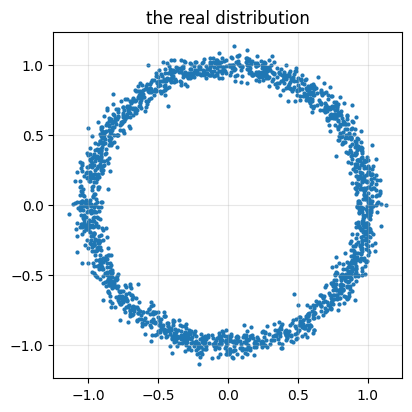

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

def real_points(n):
    # a ring, easy to look at and impossible to fit with a straight line
    angle = torch.rand(n) * 2 * np.pi
    r = 1 + 0.05 * torch.randn(n)
    return torch.stack([r * torch.cos(angle), r * torch.sin(angle)], dim=1)

data = real_points(2000)
plt.figure(figsize=(4.5,4.5))
plt.scatter(data[:,0], data[:,1], s=4)
plt.title('the real distribution')
plt.axis('equal'); plt.grid(alpha=.3)
plt.show()

## the two networks
tiny, 2 numbers in and out. the generator turns noise into a point, the discriminator scores a point.

In [2]:
Z = 8

W = 128

G = nn.Sequential(
    nn.Linear(Z, W), nn.ReLU(),
    nn.Linear(W, W), nn.ReLU(),
    nn.Linear(W, 2)
)

D = nn.Sequential(
    nn.Linear(2, W), nn.LeakyReLU(0.2),
    nn.Linear(W, W), nn.LeakyReLU(0.2),
    nn.Linear(W, 1)                  # one logit, no sigmoid, BCEWithLogits adds it
)

print("generator :", sum(p.numel() for p in G.parameters()), "parameters")
print("discriminator :", sum(p.numel() for p in D.parameters()), "parameters")

generator : 17922 parameters
discriminator : 17025 parameters


## the two losses

for the discriminator, a plain classification problem, real should score 1 and fake should score 0:

```
D_loss = BCE(D(real), 1) + BCE(D(fake), 0)
```

for the generator, the interesting one. the obvious choice is to **minimise** `BCE(D(fake), 0)`, but that gives tiny gradients early on when D is confident. so everyone uses the flipped version instead, **maximise** the chance D says real:

```
G_loss = BCE(D(fake), 1)
```

same fixed point, much better gradients at the start. this is called the non saturating loss.

In [12]:
bce = nn.BCEWithLogitsLoss()
# betas=(0.5, 0.999) instead of the default, everyone uses this for GANs.
# my first try used the defaults and it collapsed, see the note further down
opt_g = torch.optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

def d_step(real):
    n = len(real)
    fake = G(torch.randn(n, Z)).detach()          # detach, G is not being updated here
    loss = bce(D(real), torch.ones(n,1)) + bce(D(fake), torch.zeros(n,1))
    opt_d.zero_grad(); loss.backward(); opt_d.step()
    return loss.item()

def g_step(n):
    fake = G(torch.randn(n, Z))                    # no detach, gradient must reach G
    loss = bce(D(fake), torch.ones(n,1))           # G wants D to say "real"
    opt_g.zero_grad(); loss.backward(); opt_g.step()
    return loss.item()

## training, and watching it learn

In [5]:
snapshots = {}
hist_d, hist_g = [], []

BATCH = 512

for step in range(6001):
    real = real_points(BATCH)
    hist_d.append(d_step(real))
    hist_g.append(g_step(BATCH))

    if step in (0, 500, 2000, 6000):
        with torch.no_grad():
            snapshots[step] = G(torch.randn(500, Z)).numpy()

    if step % 2000 == 0:
        print("step", str(step).rjust(4), " D", round(hist_d[-1], 3), " G", round(hist_g[-1], 3))

step    0  D 1.402  G 0.714


step 2000  D 1.309  G 0.951


step 4000  D 1.382  G 0.699


step 6000  D 1.387  G 0.699


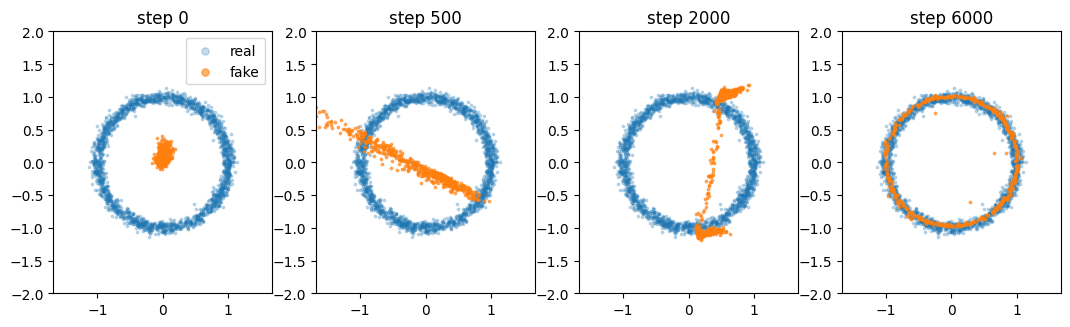

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(13,3.4))
for a, (step, pts) in zip(ax, snapshots.items()):
    a.scatter(data[:,0], data[:,1], s=3, alpha=.25, label='real')
    a.scatter(pts[:,0], pts[:,1], s=3, alpha=.6, label='fake')
    a.set_title('step ' + str(step)); a.axis('equal'); a.set_xlim(-2,2); a.set_ylim(-2,2)
ax[0].legend(markerscale=3)
plt.show()

it starts as a blob at the origin and ends up spread all the way around the ring. nobody ever told it the shape, the only signal was D saying `this does not look real`.

checking the coverage properly instead of just eyeballing it:

In [7]:
with torch.no_grad():
    final = G(torch.randn(1000, Z)).numpy()

angles = np.arctan2(final[:,1], final[:,0])
hist, _ = np.histogram(angles, bins=16, range=(-np.pi, np.pi))
radius = np.hypot(final[:,0], final[:,1])

print("angle bins holding at least 1% of the samples :", int((hist > 10).sum()), "out of 16")
print("average radius :", round(float(radius.mean()), 3), " (real data is 1.0)")

angle bins holding at least 1% of the samples : 16 out of 16
average radius : 0.999  (real data is 1.0)


all 16 bins filled and the radius is right, so it really did learn the ring and not one piece of it.

**this did not work the first time.** my first attempt used lr 2e-3, the default Adam betas, width 64 and 3000 steps. the generator collapsed onto one small blob that slid around the ring instead of covering it, so it was producing one point over and over. what fixed it:

- `betas=(0.5, 0.999)` instead of the default 0.9. lower momentum, because the thing being chased keeps moving
- half the learning rate, and a bigger batch (512) so each step is less noisy
- longer training

that failure is worth understanding rather than hiding, its called mode collapse and notebook 03 is about it.

## the losses do not go down

this is the part that confused me at first. in every other model a falling loss means progress. here the two losses fight each other, so they wander around instead.

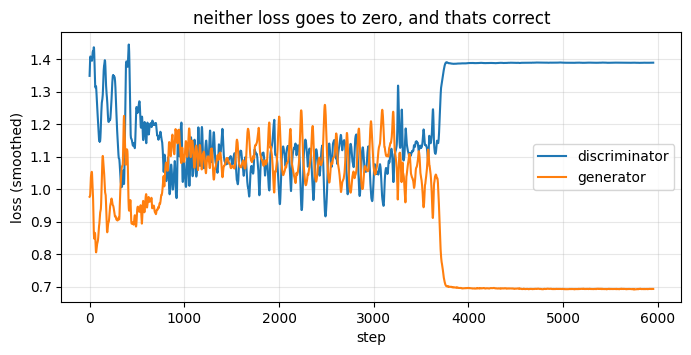

In [8]:
def smooth(v, k=50):
    return np.convolve(v, np.ones(k)/k, mode='valid')

plt.figure(figsize=(8,3.5))
plt.plot(smooth(hist_d), label='discriminator')
plt.plot(smooth(hist_g), label='generator')
plt.xlabel('step'); plt.ylabel('loss (smoothed)'); plt.legend(); plt.grid(alpha=.3)
plt.title('neither loss goes to zero, and thats correct')
plt.show()

a GAN loss curve says almost nothing about sample quality, you have to look at the samples. but there is one number worth knowing.

if D cannot tell real from fake at all it outputs 0.5 for everything, and one BCE term becomes `ln 2 = 0.693`. my D loss is the sum of the real term and the fake term, so the balanced value is `2 ln 2 = 1.386`.

In [9]:
ln2 = float(np.log(2))
print("ln(2)          :", round(ln2, 4), " <- one BCE term when D is guessing")
print("2 * ln(2)      :", round(2*ln2, 4), " <- my D loss is the sum of two terms, so this is the balanced value")
print("my D, last 200 :", round(float(np.mean(hist_d[-200:])), 3))
print("my G, last 200 :", round(float(np.mean(hist_g[-200:])), 3))

ln(2)          : 0.6931  <- one BCE term when D is guessing
2 * ln(2)      : 1.3863  <- my D loss is the sum of two terms, so this is the balanced value
my D, last 200 : 1.388
my G, last 200 : 0.693


## what D learnt

the discriminator is a classifier over the plane, so its decision surface can be drawn.

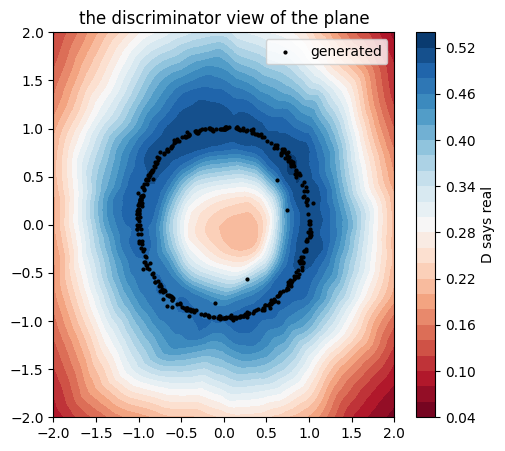

In [10]:
gx, gy = np.meshgrid(np.linspace(-2,2,120), np.linspace(-2,2,120))
grid = torch.tensor(np.stack([gx.ravel(), gy.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    scores = torch.sigmoid(D(grid)).numpy().reshape(gx.shape)
    fakes = G(torch.randn(400, Z)).numpy()

plt.figure(figsize=(5.5,5))
plt.contourf(gx, gy, scores, levels=25, cmap='RdBu')
plt.colorbar(label='D says real')
plt.scatter(fakes[:,0], fakes[:,1], s=4, c='k', label='generated')
plt.legend(); plt.title('the discriminator view of the plane')
plt.show()

my run finished at 1.388 against a theoretical 1.386, and G at 0.699 against 0.693. thats the equilibrium the theory predicts, D is reduced to a coin flip. i did not expect it to land that exactly.

## what D learnt

the discriminator is a classifier over the plane, so its decision surface can be drawn.